# Week 3 Day 3 — Logistic Regression and Classification Metrics

## BinX Tech AI & Machine Learning Internship

### Objectives

In this notebook, I will:

- Load a real binary classification dataset.
- inspect the features and target.
- separate the data into features `X` and target `y`.
- split the data into training and testing sets.
- scale the features using `StandardScaler`.
- train a logistic regression classifier.
- generate class predictions and class probabilities.
- evaluate the classifier using accuracy, precision, recall, and F1-score.
- create and interpret a confusion matrix.
- calculate and visualize the ROC curve.
- calculate AUC-ROC.
- explain whether precision or recall is more important for this problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Dataset

The Breast Cancer Wisconsin dataset is a binary classification dataset.

The target classes are:

- `0`: malignant
- `1`: benign

The objective is to predict whether a tumor is malignant or benign using measurements calculated from digitized images of breast masses.

In [6]:
import pandas as pd

cancer_data = pd.read_csv('BreastCancer.csv')

X = cancer_data.drop(columns=['Id', 'Class'])

y = cancer_data['Class']

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [8]:
import pandas as pd

cancer_data = pd.read_csv('BreastCancer.csv')

X = cancer_data.drop(columns=['Id', 'Class'])
y = cancer_data['Class']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:", y.unique())
print("\nFirst five rows of the features:")
display(X.head())


Feature matrix shape: (699, 9)
Target shape: (699,)

Target classes: [0 1]

First five rows of the features:


,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [10]:
target_counts = y.value_counts().sort_index()

target_summary = pd.DataFrame({
    "Class Number": target_counts.index,
    "Number of Samples": target_counts.values
})

display(target_summary)


,Class Number,Number of Samples
0,0,458
1,1,241


In [11]:
missing_values = X.isnull().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 16


In [13]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})

class_distribution.index = ['Benign (2)', 'Malignant (4)']
display(class_distribution)


,Count,Percentage
Benign (2),458,65.52
Malignant (4),241,34.48


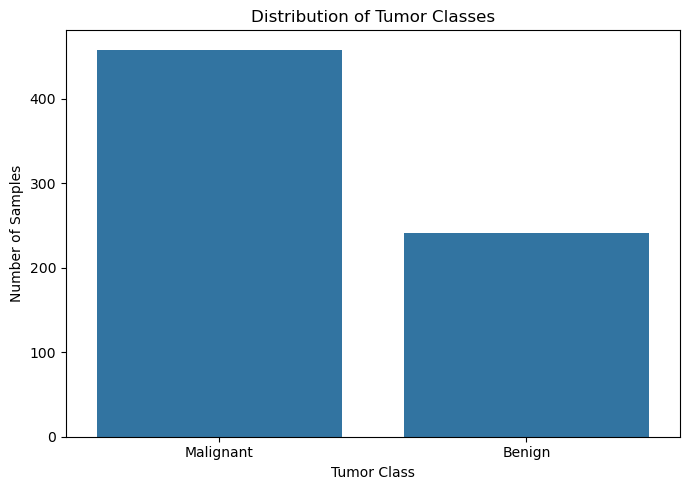

In [14]:
target_labels = y.map({
    0: "Malignant",
    1: "Benign"
})

plt.figure(figsize=(7, 5))

sns.countplot(x=target_labels)

plt.title("Distribution of Tumor Classes")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### Target Distribution Interpretation

The dataset contains both malignant and benign samples.

The classes are not perfectly balanced because benign cases are more common than malignant cases. Therefore, accuracy should not be used alone when evaluating the classifier.

Metrics such as precision, recall, F1-score, and AUC-ROC provide a more complete evaluation.

## 2. Split the Dataset

The feature matrix is stored in `X`, while the classification target is stored in `y`.

The dataset will be divided into:

- 80% training data
- 20% testing data

The model learns only from the training data. The test data remains unseen during training and is used for final evaluation.

Because this is a classification problem, `stratify=y` is used to preserve approximately the same class proportions in both sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (559, 9)
X_test shape: (140, 9)
y_train shape: (559,)
y_test shape: (140,)


In [17]:
train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .rename("Training Proportion")
)
test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .rename("Testing Proportion")
)
distribution_comparison = pd.concat(
    [train_distribution, test_distribution], axis=1
)
distribution_comparison.index = ["Benign (2)", "Malignant (4)"]
display(distribution_comparison.round(3))


,Training Proportion,Testing Proportion
Benign (2),0.655,0.657
Malignant (4),0.345,0.343


## 3. Feature Scaling

Logistic regression is affected by differences in feature scales.

For example, some features may contain small decimal values while others may contain values in the hundreds or thousands. `StandardScaler` transforms each feature so that it has approximately:

- mean = 0
- standard deviation = 1

The scaler must be fitted only on the training data to prevent data leakage.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled shape:", X_train_scaled.shape)
print("Testing data scaled shape:", X_test_scaled.shape)

Training data scaled shape: (559, 9)
Testing data scaled shape: (140, 9)


## 4. Train the Logistic Regression Model

Logistic regression is a classification algorithm.

It calculates a weighted combination of the input features and transforms the result into a probability using the sigmoid function.

For binary classification:

- probabilities below the decision threshold are assigned to one class;
- probabilities above the threshold are assigned to the other class.

The default threshold is usually `0.5`.

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_scaled)

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_imputed, y_train)
print("Logistic regression model trained successfully.")


Logistic regression model trained successfully.


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(SimpleImputer(strategy="median"), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)


In [26]:
X_test_imputed = imputer.transform(X_test_scaled)

y_pred = logistic_model.predict(X_test_imputed)
print("First 10 predicted classes:")
print(y_pred[:10])


First 10 predicted classes:
[1 0 0 0 1 1 0 0 0 0]


In [28]:
X_test_imputed = imputer.transform(X_test_scaled)

y_probabilities = logistic_model.predict_proba(X_test_imputed)
print("Probability array shape:", y_probabilities.shape)
print("\nFirst five probability pairs:")
print(y_probabilities[:5])


Probability array shape: (140, 2)

First five probability pairs:
[[1.85780676e-02 9.81421932e-01]
 [9.98279830e-01 1.72016994e-03]
 [9.65545049e-01 3.44549515e-02]
 [9.96815069e-01 3.18493137e-03]
 [8.30504264e-04 9.99169496e-01]]


In [29]:
prediction_results = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred,
    "Probability Malignant": y_probabilities[:, 0],
    "Probability Benign": y_probabilities[:, 1]
})

prediction_results["Actual Label"] = prediction_results[
    "Actual Class"
].map({
    0: "Malignant",
    1: "Benign"
})

prediction_results["Predicted Label"] = prediction_results[
    "Predicted Class"
].map({
    0: "Malignant",
    1: "Benign"
})

display(prediction_results.head(10))

,Actual Class,Predicted Class,Probability Malignant,Probability Benign,Actual Label,Predicted Label
0,1,1,0.018578,0.981422,Benign,Benign
1,0,0,0.998280,0.001720,Malignant,Malignant
2,0,0,0.965545,0.034455,Malignant,Malignant
3,0,0,0.996815,0.003185,Malignant,Malignant
4,1,1,0.000831,0.999169,Benign,Benign
5,1,1,0.000435,0.999565,Benign,Benign
6,0,0,0.997539,0.002461,Malignant,Malignant
7,0,0,0.996760,0.003240,Malignant,Malignant
8,0,0,0.984405,0.015595,Malignant,Malignant
9,0,0,0.998280,0.001720,Malignant,Malignant


## 5. Classification Metrics

The classifier will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- AUC-ROC

Because Scikit-learn treats class `1` as the positive class by default, the default binary metrics initially describe performance for the benign class.

For the medical interpretation, additional metrics will also be calculated while treating malignant tumors, class `0`, as the clinically important positive condition.

In [30]:
accuracy = accuracy_score(y_test, y_pred)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

general_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score"
    ],
    "Score": [
        accuracy,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

general_metrics["Score"] = general_metrics["Score"].round(4)

display(general_metrics)

,Metric,Score
0,Accuracy,0.9500
1,Weighted Precision,0.9499
2,Weighted Recall,0.9500
3,Weighted F1-score,0.9499


In [32]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test, 
    y_pred, 
    target_names=['Benign', 'Malignant'], 
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))


,precision,recall,f1-score,support
Benign,0.9570,0.9674,0.9622,92.00
Malignant,0.9362,0.9167,0.9263,48.00
accuracy,0.9500,0.9500,0.9500,0.95
macro avg,0.9466,0.9420,0.9442,140.00
weighted avg,0.9499,0.9500,0.9499,140.00


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.96      0.97      0.96        92
   Malignant       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140



## 6. Confusion Matrix

A confusion matrix divides predictions into four possible outcomes:

- True Positive
- False Positive
- False Negative
- True Negative

In this dataset:

- class `0` represents malignant;
- class `1` represents benign.

The matrix will show how many malignant and benign cases were classified correctly or incorrectly.

In [35]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[89  3]
 [ 4 44]]


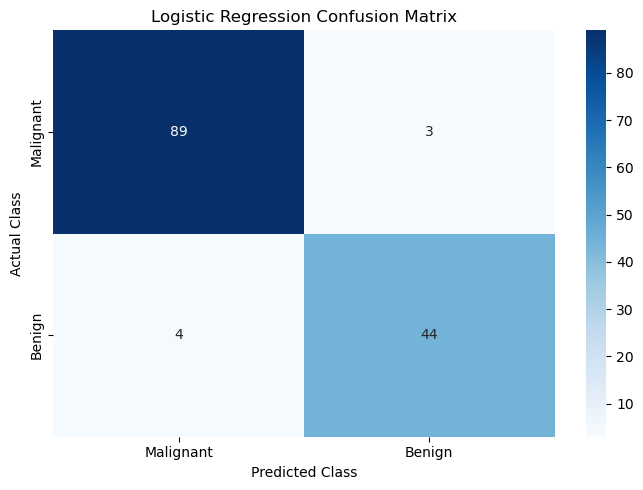

In [36]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [37]:
actual_malignant = y_test == 0
predicted_malignant = y_pred == 0

malignant_true_positive = np.sum(
    actual_malignant & predicted_malignant
)

malignant_false_negative = np.sum(
    actual_malignant & ~predicted_malignant
)

malignant_false_positive = np.sum(
    ~actual_malignant & predicted_malignant
)

malignant_true_negative = np.sum(
    ~actual_malignant & ~predicted_malignant
)

clinical_confusion_values = pd.DataFrame({
    "Outcome": [
        "True Positive: malignant correctly detected",
        "False Negative: malignant incorrectly predicted benign",
        "False Positive: benign incorrectly predicted malignant",
        "True Negative: benign correctly detected"
    ],
    "Count": [
        malignant_true_positive,
        malignant_false_negative,
        malignant_false_positive,
        malignant_true_negative
    ]
})

display(clinical_confusion_values)

,Outcome,Count
0,True Positive: malignant correctly detected,89
1,False Negative: malignant incorrectly predicte...,3
2,False Positive: benign incorrectly predicted m...,4
3,True Negative: benign correctly detected,44


In [38]:
malignant_precision = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

malignant_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

malignant_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

malignant_metrics = pd.DataFrame({
    "Metric": [
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1-score"
    ],
    "Score": [
        malignant_precision,
        malignant_recall,
        malignant_f1
    ]
})

malignant_metrics["Score"] = malignant_metrics["Score"].round(4)

display(malignant_metrics)

,Metric,Score
0,Malignant Precision,0.9570
1,Malignant Recall,0.9674
2,Malignant F1-score,0.9622


### Confusion Matrix and Metric Interpretation

The confusion matrix shows how many malignant and benign tumors were classified correctly and incorrectly.

For malignant cases:

- **Precision** measures how many tumors predicted as malignant were actually malignant.
- **Recall** measures how many actual malignant tumors were successfully detected.
- **F1-score** balances malignant precision and malignant recall.

For this medical classification problem, **recall for the malignant class is more important than precision**.

A false negative means that an actual malignant tumor was predicted as benign. This is potentially more harmful than a false positive because it may delay additional testing or treatment.

Therefore, the model should prioritize detecting as many real malignant cases as possible, while still monitoring false-positive predictions.

In [39]:
y_test_malignant_positive = (y_test == 0).astype(int)

malignant_probabilities = y_probabilities[:, 0]

print("First 10 malignant probabilities:")
print(malignant_probabilities[:10])

First 10 malignant probabilities:
[1.85780676e-02 9.98279830e-01 9.65545049e-01 9.96815069e-01
 8.30504264e-04 4.34812534e-04 9.97538649e-01 9.96760135e-01
 9.84405108e-01 9.98279830e-01]


In [40]:
fpr, tpr, thresholds = roc_curve(
    y_test_malignant_positive,
    malignant_probabilities
)

auc_score = roc_auc_score(
    y_test_malignant_positive,
    malignant_probabilities
)

print(f"AUC-ROC for malignant detection: {auc_score:.4f}")

AUC-ROC for malignant detection: 0.9950


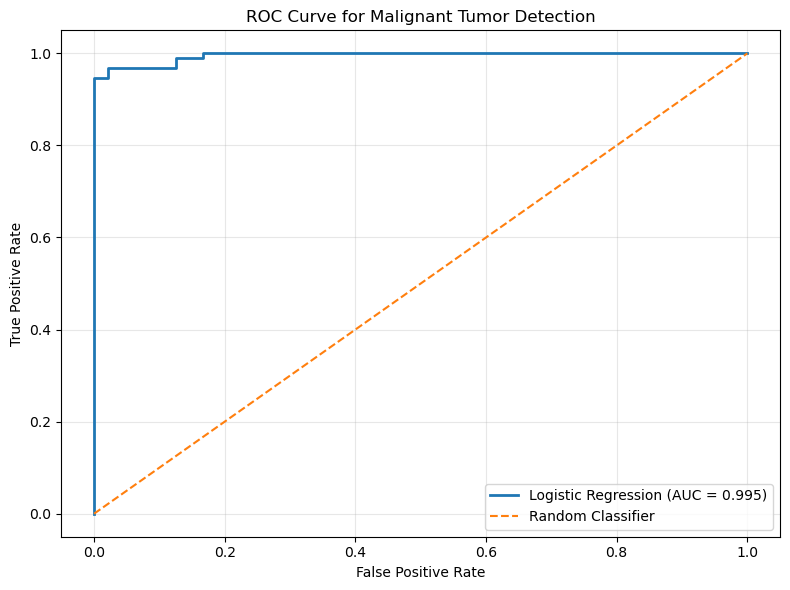

In [41]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve for Malignant Tumor Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ROC-AUC Interpretation

The ROC curve illustrates the model's behavior across multiple classification thresholds.

The AUC-ROC score measures how well the model separates malignant tumors from benign tumors.

An AUC close to `1.0` indicates strong discrimination between the two classes. An AUC close to `0.5` would indicate performance similar to random guessing.

Based on the calculated AUC, the logistic regression model demonstrates strong ability to distinguish malignant cases from benign cases.

In [42]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_table["Absolute Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(coefficient_table.head(10))

,Feature,Coefficient,Absolute Coefficient
5,Bare.nuclei,1.646640,1.646640
0,Cl.thickness,1.183722,1.183722
6,Bl.cromatin,0.876616,0.876616
8,Mitoses,0.790149,0.790149
2,Cell.shape,0.759407,0.759407
3,Marg.adhesion,0.576472,0.576472
7,Normal.nucleoli,0.562711,0.562711
4,Epith.c.size,0.183990,0.183990
1,Cell.size,0.121883,0.121883


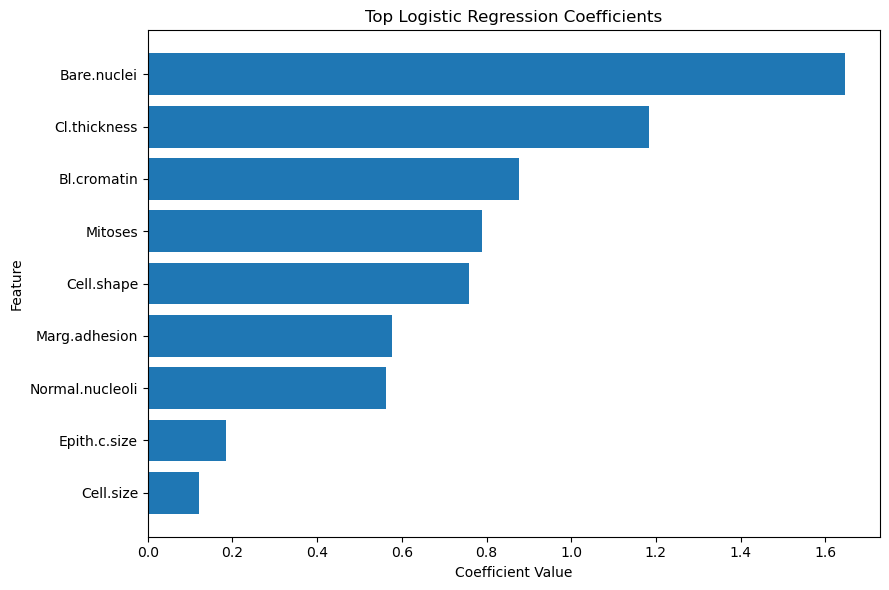

In [43]:
top_coefficients = coefficient_table.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Coefficient Interpretation

The coefficients indicate how each scaled feature contributes to the logistic regression decision.

Because class `1` represents benign tumors:

- a positive coefficient pushes the prediction toward the benign class;
- a negative coefficient pushes the prediction toward the malignant class.

The absolute coefficient size indicates how strongly the feature influences the model after scaling.

However, coefficients should not automatically be interpreted as proof that a feature causes the outcome.

In [44]:
incorrect_predictions = prediction_results[
    prediction_results["Actual Class"]
    != prediction_results["Predicted Class"]
].copy()

print(
    "Number of incorrect predictions:",
    len(incorrect_predictions)
)

display(incorrect_predictions)

Number of incorrect predictions: 7


,Actual Class,Predicted Class,Probability Malignant,Probability Benign,Actual Label,Predicted Label
11,1,0,0.748835,0.251165,Benign,Malignant
17,1,0,0.764018,0.235982,Benign,Malignant
21,1,0,0.520596,0.479404,Benign,Malignant
52,0,1,0.086845,0.913155,Malignant,Benign
59,0,1,0.332471,0.667529,Malignant,Benign
86,0,1,0.264055,0.735945,Malignant,Benign
125,1,0,0.933189,0.066811,Benign,Malignant


In [45]:
false_negatives_malignant = incorrect_predictions[
    (incorrect_predictions["Actual Class"] == 0)
    & (incorrect_predictions["Predicted Class"] == 1)
]

false_positives_malignant = incorrect_predictions[
    (incorrect_predictions["Actual Class"] == 1)
    & (incorrect_predictions["Predicted Class"] == 0)
]

print(
    "Malignant cases incorrectly predicted as benign:",
    len(false_negatives_malignant)
)

print(
    "Benign cases incorrectly predicted as malignant:",
    len(false_positives_malignant)
)

Malignant cases incorrectly predicted as benign: 3
Benign cases incorrectly predicted as malignant: 4


In [46]:
final_evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score",
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1-score",
        "AUC-ROC for Malignant Detection"
    ],
    "Score": [
        accuracy,
        weighted_precision,
        weighted_recall,
        weighted_f1,
        malignant_precision,
        malignant_recall,
        malignant_f1,
        auc_score
    ]
})

final_evaluation["Score"] = final_evaluation["Score"].round(4)

display(final_evaluation)

,Metric,Score
0,Accuracy,0.9500
1,Weighted Precision,0.9499
2,Weighted Recall,0.9500
3,Weighted F1-score,0.9499
4,Malignant Precision,0.9570
5,Malignant Recall,0.9674
6,Malignant F1-score,0.9622
7,AUC-ROC for Malignant Detection,0.9950


## Final Conclusion

In this notebook, I completed a binary classification workflow using logistic regression.

The implementation included:

1. Loading and inspecting a real classification dataset.
2. Separating the data into features and target.
3. Creating a stratified training and testing split.
4. Scaling the features without leaking test-set information.
5. Training a logistic regression classifier.
6. Generating predicted classes and class probabilities.
7. Evaluating the model with accuracy, precision, recall, and F1-score.
8. Creating and interpreting a confusion matrix.
9. Evaluating malignant-case detection specifically.
10. Calculating and plotting the ROC curve.
11. Calculating AUC-ROC.
12. Examining model coefficients and incorrect predictions.

Accuracy alone was not sufficient for this problem. Recall for malignant tumors was especially important because a false negative represents a malignant case incorrectly classified as benign.

The logistic regression model provided an interpretable baseline classifier and demonstrated how classification performance must be evaluated using multiple complementary metrics.